In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os


from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
def explore_column(df, col, transform=False):
    """
    Explore a single column in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to explore.
    col (str): The column name to explore.
    
    Returns:
    None
    """
    # Check if the column exists in the DataFrame
    if col not in df.columns:
        print(f"Column '{col}' does not exist in the DataFrame.")
        return
    
    
    if transform:
        # reverse log transform
        df[col] = np.exp(df[col]) - 1


    # Display basic statistics
    print(f"Statistics for column '{col}':")
    print(df[col].describe())
    print("\n")


    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    if df[col].nunique() < 10:
        print(f"Unique values in '{col}': {df[col].unique()}")
    else:
        print(f"First 10 unique values in '{col}': {df[col].unique()[:10]}")
    print("\n")
    
    # Display missing values
    missing_values = df[col].isnull().sum()
    print(f"Missing values in '{col}': {missing_values}")
    print(f"Percentage of missing values in '{col}': {missing_values / len(df) * 100:.2f}%")


            
    # Plot the distribution of the column
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [119]:
df = pd.read_csv('data/training_set_VU_DM.csv')
df["date_time"] = pd.to_datetime(df["date_time"])

Statistics for column 'srch_booking_window':
count    4.958347e+06
mean     3.747417e+01
std      5.199341e+01
min      0.000000e+00
25%      4.000000e+00
50%      1.700000e+01
75%      4.800000e+01
max      4.920000e+02
Name: srch_booking_window, dtype: float64


Number of unique values in 'srch_booking_window': 429
First 10 unique values in 'srch_booking_window': [  0  46   5  39  21 194  62  27 144  13]


Missing values in 'srch_booking_window': 0
Percentage of missing values in 'srch_booking_window': 0.00%


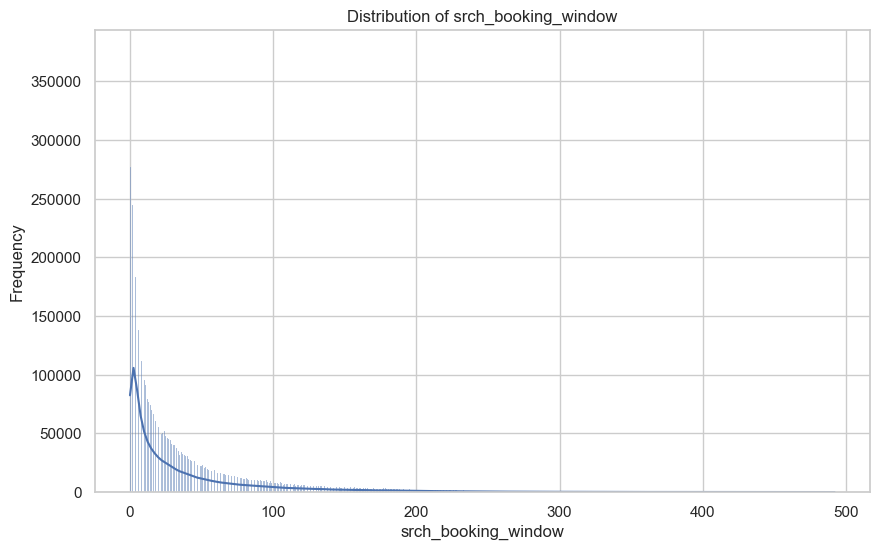

In [134]:
explore_column(df, "srch_booking_window", transform=False)

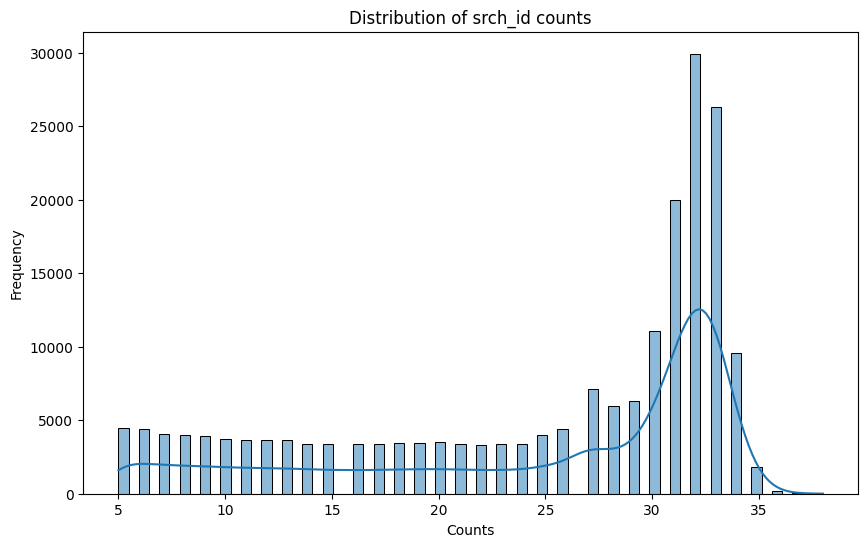

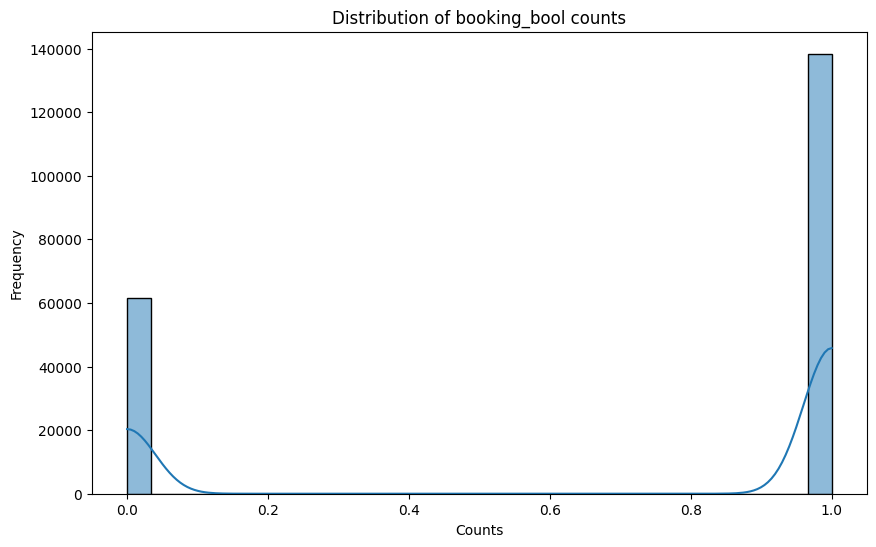

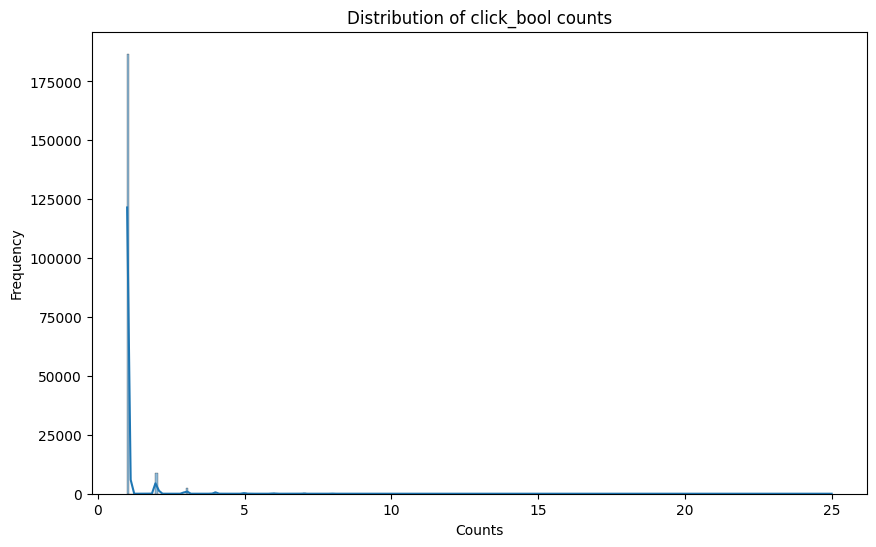

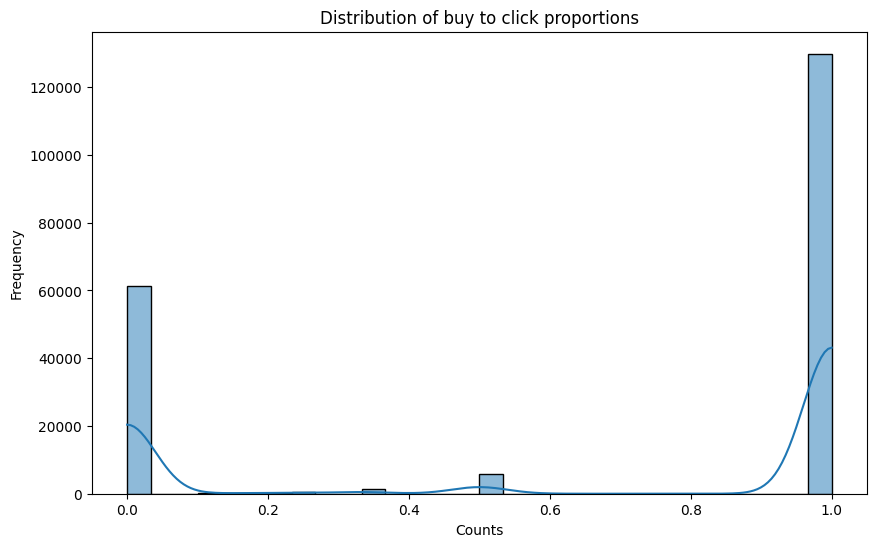

Unique counts of click_bool and their frequencies:
click_bool
1     186764
2       8772
3       2281
4        900
5        426
6        279
7        144
8         88
9         47
11        27
10        20
13        10
12        10
14         7
16         7
15         6
20         2
17         2
24         1
19         1
25         1
Name: count, dtype: int64
Unique counts of click_bool: [ 1  3  2  6  7  5  9 19 11 10  4  8 15 13 12 24 14 20 17 16 25]


In [24]:
# count how many rows groupped by srch_id



srch_id_counts = df.groupby("srch_id").size().reset_index(name="counts")
srch_id_counts
# in each group, count how many rows have booking_bool == 1
srch_id_counts["booking_bool"] = df.groupby("srch_id")["booking_bool"].sum().values
srch_id_counts["click_bool"] = df.groupby("srch_id")["click_bool"].sum().values

# create a column dividing booking_bool by click_count
srch_id_counts["booking_bool_prop"] = srch_id_counts["booking_bool"] / srch_id_counts["click_bool"]



# plot the distribution of srch_id counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["counts"], kde=True)
plt.title("Distribution of srch_id counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# plot the distribution of booking_bool counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["booking_bool"], kde=True)
plt.title("Distribution of booking_bool counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# plot the distribution of click_bool counts
plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["click_bool"], kde=True, bins=300)
plt.title("Distribution of click_bool counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(srch_id_counts["booking_bool_prop"], kde=True)
plt.title("Distribution of buy to click proportions")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.show()

# print unique counts of click_bool and their frequencies
click_bool_counts = srch_id_counts["click_bool"].value_counts()
print("Unique counts of click_bool and their frequencies:")
print(click_bool_counts)
print(f"Unique counts of click_bool: {srch_id_counts['click_bool'].unique()}")

### bool preedictions

In [29]:
# train-test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=["booking_bool", "click_bool", "gross_bookings_usd", "srch_id", "date_time", "position"])
y1 = df["booking_bool"]
y2 = df["click_bool"]
y3 = df["gross_bookings_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)
# X_train, X_test, y_train3, y_test3 = train_test_split(X, y3, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3966677, 49)
X_test shape: (991670, 49)
y_train shape: (3966677,)
y_test shape: (991670,)


In [30]:

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train,
)


# Train the model
model_book = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_click = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# Fit the model
model_book.fit(X_train, y_train, sample_weight=sample_weights)
model_click.fit(X_train, y_train2, sample_weight=sample_weights)



/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:28:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:28:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

                Model  Accuracy  F1 Score  Precision  Recall  ROC AUC
0  Booking Bool Model       1.0       1.0        1.0     1.0      1.0
1    Click Bool Model       1.0       1.0        1.0     1.0      1.0


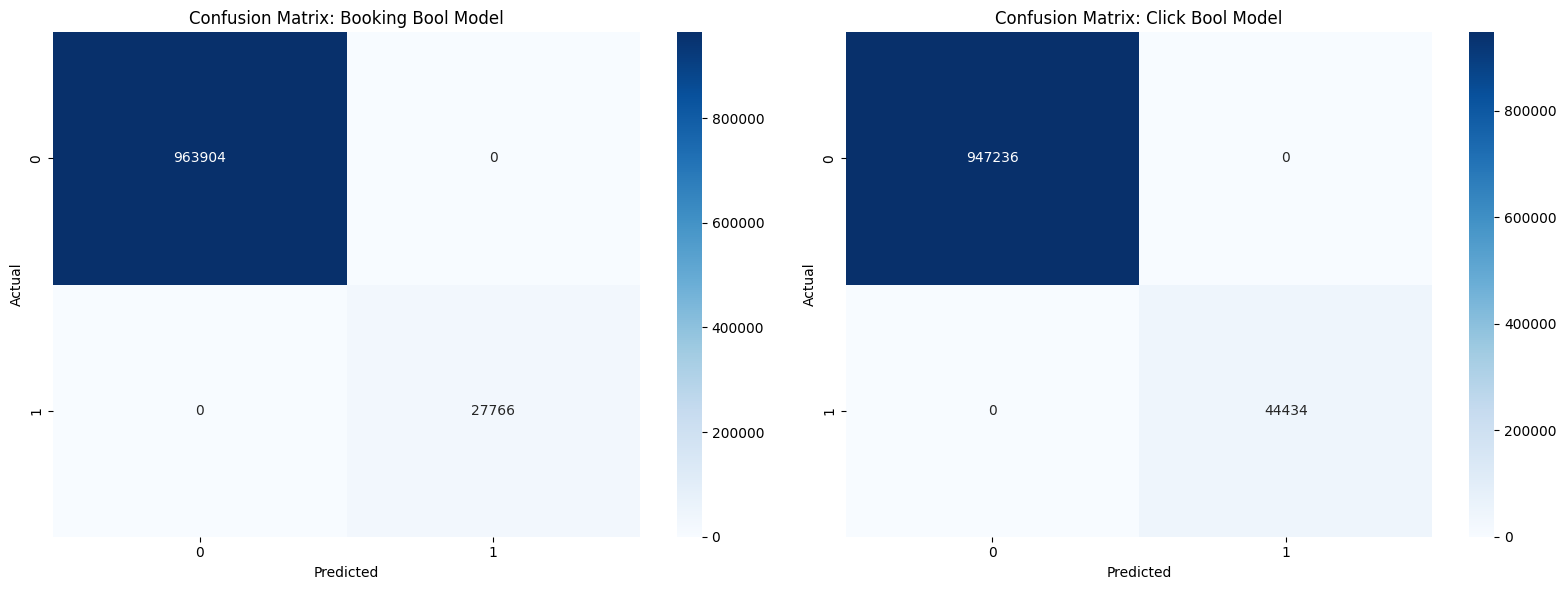

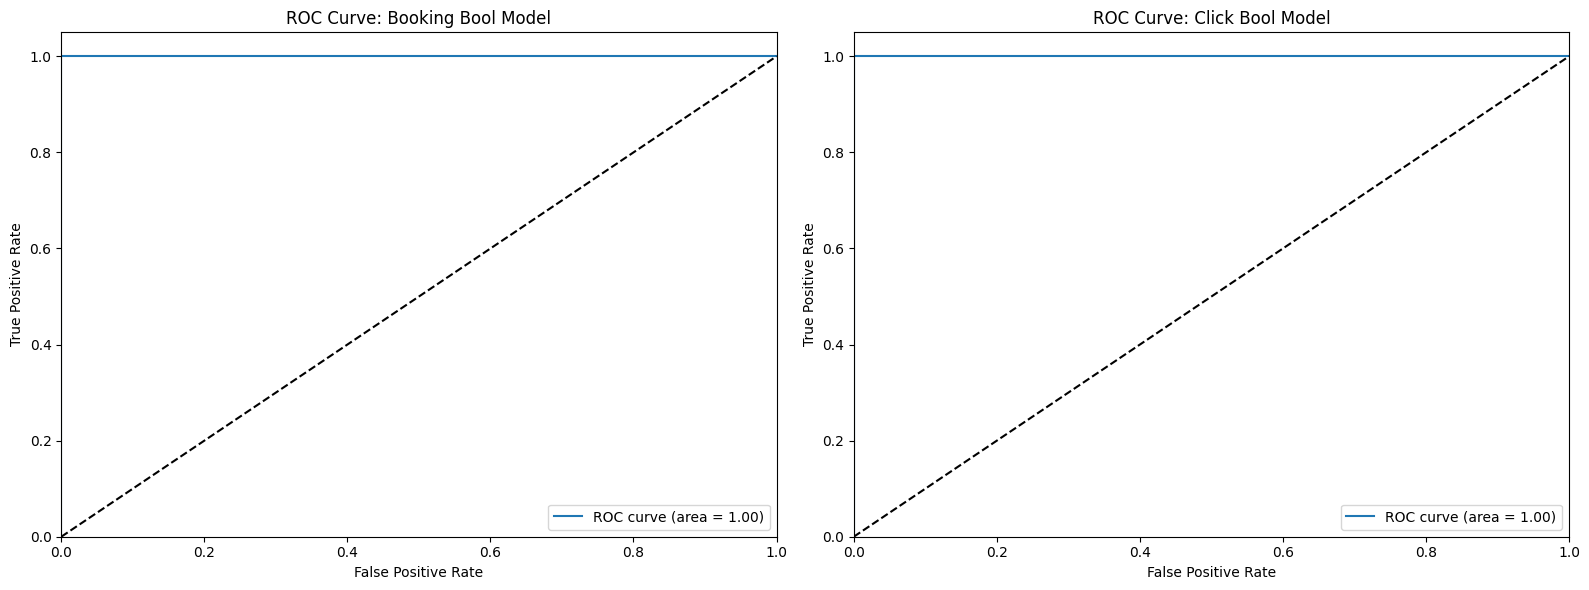

/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_62296/2865987714.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_62296/2865987714.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


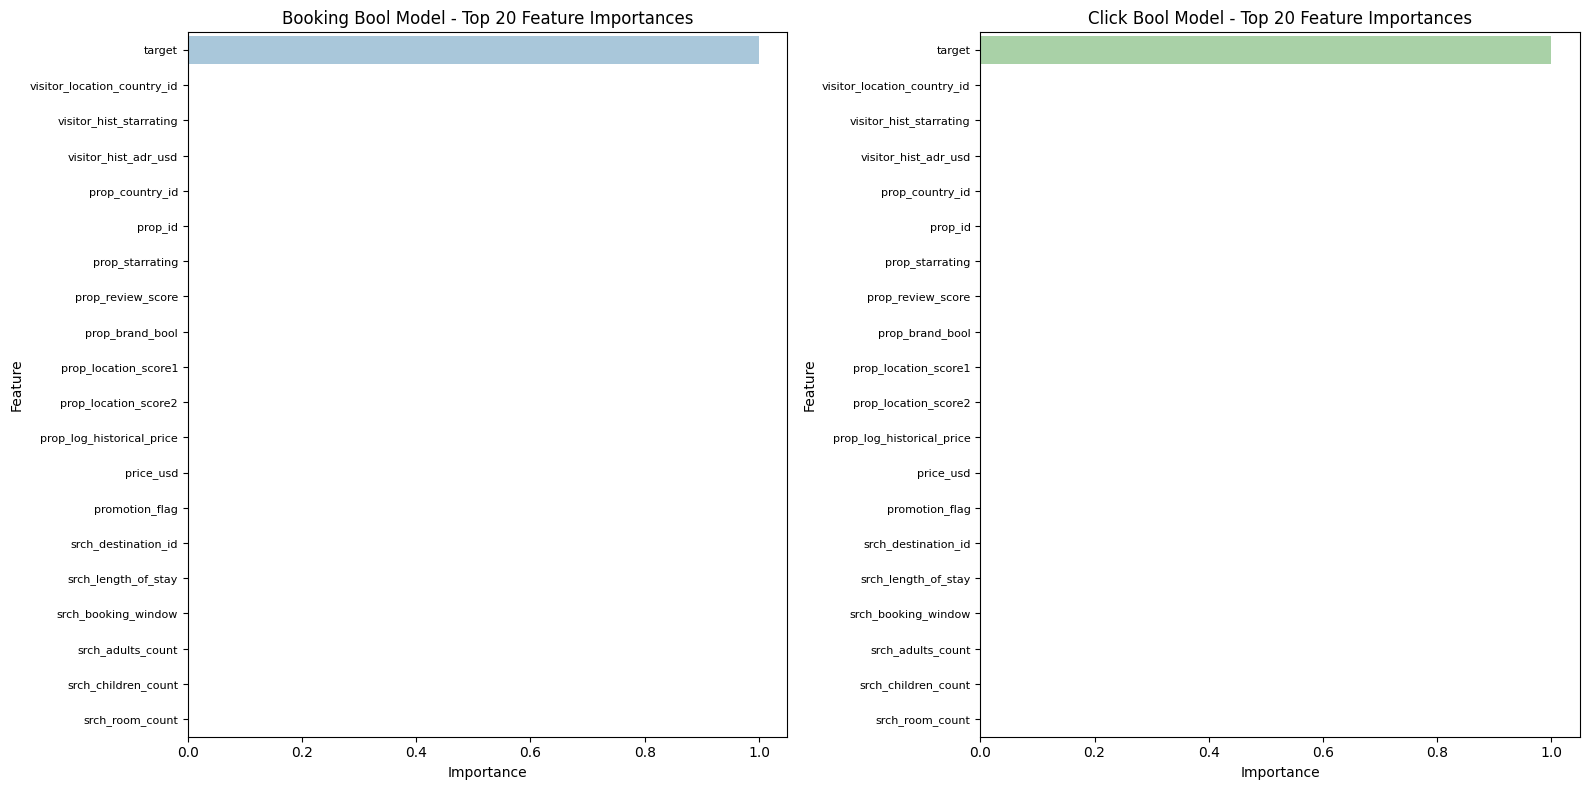

In [31]:
# Make predictions
y_pred = model_book.predict(X_test)
y_pred2 = model_click.predict(X_test)

# Evaluate the models
metrics = {
    "Model": ["Booking Bool Model", "Click Bool Model"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test2, y_pred2)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test2, y_pred2)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test2, y_pred2)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test2, y_pred2)],
    "ROC AUC": [roc_auc_score(y_test, y_pred), roc_auc_score(y_test2, y_pred2)],
}

# Print metrics
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix: Booking Bool Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix: Click Bool Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Plot ROC curves side by side
y_pred_proba_book = model_book.predict_proba(X_test)[:, 1]
y_pred_proba_click = model_click.predict_proba(X_test)[:, 1]

fpr_book, tpr_book, _ = roc_curve(y_test, y_pred_proba_book)
fpr_click, tpr_click, _ = roc_curve(y_test2, y_pred_proba_click)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(fpr_book, tpr_book, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba_book))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Booking Bool Model')
axes[0].legend(loc='lower right')

axes[1].plot(fpr_click, tpr_click, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test2, y_pred_proba_click))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Click Bool Model')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Feature importance
importance_book = model_book.feature_importances_
importance_click = model_click.feature_importances_
feature_names = X.columns
importance_df_book = pd.DataFrame(importance_book, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)
importance_df_click = pd.DataFrame(importance_click, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)


# Prepare sorted DataFrames for top features (make feature names a column)
feat_imp_book = (
  importance_df_book
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

feat_imp_click = (
  importance_df_click
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_book,
    ax=axes[0], palette="Blues_d"
)
axes[0].set_title("Booking Bool Model - Top 20 Feature Importances")
axes[0].tick_params(axis="y", labelsize=8)

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_click,
    ax=axes[1], palette="Greens_d"
)
axes[1].set_title("Click Bool Model - Top 20 Feature Importances")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


### Feature engineering

In [74]:
data = pd.read_csv('data/training_set_VU_DM.csv')


In [ ]:
# explore missing values
data.isnull().sum()
# in percent
data.isnull().sum() / len(data) * 100


srch_id                         0.000000
date_time                       0.000000
site_id                         0.000000
visitor_location_country_id     0.000000
visitor_hist_starrating        94.920364
visitor_hist_adr_usd           94.897735
prop_country_id                 0.000000
prop_id                         0.000000
prop_starrating                 0.000000
prop_review_score               0.148517
prop_brand_bool                 0.000000
prop_location_score1            0.000000
prop_location_score2           21.990151
prop_log_historical_price       0.000000
position                        0.000000
price_usd                       0.000000
promotion_flag                  0.000000
srch_destination_id             0.000000
srch_length_of_stay             0.000000
srch_booking_window             0.000000
srch_adults_count               0.000000
srch_children_count             0.000000
srch_room_count                 0.000000
srch_saturday_night_bool        0.000000
srch_query_affin

In [174]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm.auto import tqdm


class PreprocessingService:
    def __init__(self, df, encoder=None, is_test=False):
        self.df = df.copy()
        self.feature_cols = [c for c in df.columns
                             if c not in ['target','click_bool',
                                          'booking_bool','date_time','gross_bookings_usd', "position"]]

        self.encoder = encoder if encoder else None # for probability encoding

        self.is_test = is_test

            

    def add_time_features(self):
        # Add features here
        self.df['date_time'] = pd.to_datetime(self.df['date_time'])
        self.df['day_of_week'] = self.df['date_time'].dt.dayofweek
        self.df['hour_of_day'] = self.df['date_time'].dt.hour
        self.df['month'] = self.df['date_time'].dt.month
        self.df['year'] = self.df['date_time'].dt.year
        print("Added time features")

    def add_vacation_dates(self):
        self.df["date_time"] = pd.to_datetime(self.df["date_time"])
        # Get the vacation date
        self.df["vacation_date"] = self.df["date_time"] + pd.to_timedelta(self.df["srch_booking_window"], unit="D")
        self.df["vacation_date"] = pd.to_datetime(self.df["vacation_date"])
        self.df["vacation_day_of_week"] = self.df["vacation_date"].dt.dayofweek
        self.df["vacation_month"] = self.df["vacation_date"].dt.month
        self.df["vacation_year"] = self.df["vacation_date"].dt.year
        print("Added vacation time features")

            
    ### Price features
    def add_relative_price(self):
        self.df["relative_price_mean"] = self.df.groupby("srch_id")["price_usd"].transform(lambda x: x / x.mean())
        print("Added relative price (per query) feature")

    def add_price_per_person(self):
        self.df["price_per_person"] = self.df["price_usd"] / (self.df["srch_adults_count"] + self.df["srch_children_count"])
        print("Added price per person feature")

    def add_price_per_room(self):
        self.df["price_per_room"] = self.df["price_usd"] / self.df["srch_room_count"]
        print("Added price per room feature")

    def add_price_per_person_per_room(self):
        self.df["price_per_person_per_room"] = self.df["price_usd"] / ((self.df["srch_adults_count"] + self.df["srch_children_count"]) * self.df["srch_room_count"])
        print("Added price per person per room feature")

    def add_relative_hotel_price_per_date(self):
        # NOTE: maybe we should be looking at a destination level instead of hotel level
        # ensure vacation_month & price_per_person_per_room exist
        if "vacation_month" not in self.df.columns:
            self.add_vacation_dates()
        if "price_per_person_per_room" not in self.df.columns:
            self.add_price_per_person_per_room()

        # per‐hotel per‐month mean
        month_means = self.df.groupby(
            ["prop_id", "vacation_month"]
        )["price_per_person_per_room"].transform("mean")
        # per‐hotel overall std
        prop_stds = self.df.groupby(
            "prop_id"
        )["price_per_person_per_room"].transform("std")

        # z‐score: (this month’s price − hotel×month mean) ÷ hotel std
        self.df["rel_hotel_price_per_date_z"] = (
            self.df["price_per_person_per_room"] - month_means
        ) / prop_stds
        print("Added relative hotel price per date feature (within prop_id)")

        # print range of the new feature
    
    def add_relative_hotel_price(self):
        # ensure price_per_person_per_room exists
        if "price_per_person_per_room" not in self.df.columns:
            self.add_price_per_person_per_room()

        # z-score the price per person per room within the same prop_id
        self.df["rel_hotel_price_z"] = (
            self.df["price_per_person_per_room"] - self.df.groupby("prop_id")["price_per_person_per_room"].transform("mean")
        ) / self.df.groupby("prop_id")["price_per_person_per_room"].transform("std")
        # print(self.df["rel_hotel_price_z"].describe())
        print("Added relative hotel price feature (within prop_id)")

    def location_to_price_ratio(self):
        # Calculate the ratio of price to location score
        self.df["location_to_price_ratio1"] = self.df["prop_location_score1"] / self.df["price_per_person_per_room"]
        self.df["location_to_price_ratio2"] = self.df["prop_location_score2"] / self.df["price_per_person_per_room"]
        print("Added price to location ratio feature")

    ### Customer features
    def new_customer(self):
        self.df["new_customer"] = np.where(self.df["visitor_hist_starrating"] == 0, 1, 0)
        print("Added new customer flag")
    
    def usually_spends_vs_price(self):
        # Calculate the ratio of the average price to the average starrating
        self.df["usually_spends_vs_price"] = self.df["visitor_hist_starrating"] / self.df["price_per_person_per_room"]
        print("Added usually spends vs price feature")
    

    # Booking Features
    def domestic_trip(self):
        # Check if the user is booking a hotel in their own country
        self.df["domestic_trip"] = np.where(self.df["prop_country_id"] == self.df["visitor_location_country_id"], 1, 0)
        print("Added domestic trip flag")

    ### Within query features
    def rank_price_in_query(self):
        # Rank the price in each query
        self.df["price_rank"] = self.df.groupby("srch_id")["price_usd"].rank()
        print("Added price rank feature (within query)")

    def add_relative_location_score(self):
        # z-score the prop_review_score within the same querry
        self.df["rel_location_score_z_within_srch2"] = (
            self.df["prop_location_score2"] - self.df.groupby("srch_id")["prop_location_score2"].transform("mean") 
        ) / self.df.groupby("srch_id")["prop_location_score2"].transform("std")

        self.df["rel_location_score_z_within_srch1"] = (
            self.df["prop_location_score1"] - self.df.groupby("srch_id")["prop_location_score1"].transform("mean") 
        ) / self.df.groupby("srch_id")["prop_location_score1"].transform("std")
        print("Added relative location scores (1 and 2) feature (within query)")


    ### IMPUTATION
    def impute_ratings(self):
        mean_review = self.df["prop_review_score"].replace(0, np.nan).mean()
        mean_star   = self.df["prop_starrating"].replace(0, np.nan).mean()
        self.df.fillna({
            "prop_review_score": mean_review,
            "prop_starrating": mean_star
        }, inplace=True)

        # also replace any remaining 0s (in case 0 wasn't null)
        self.df["prop_review_score"] = self.df["prop_review_score"].replace(0, mean_review)
        self.df["prop_starrating"]   = self.df["prop_starrating"].replace(0, mean_star)


    def impute_location_score2(self):
        # regression imputation based on prop_location_score1
        model = LinearRegression()
        # fit the model on the non-missing values
        mask = self.df["prop_location_score2"].notna()
        X = self.df.loc[mask, ["prop_location_score1"]]
        y = self.df.loc[mask, "prop_location_score2"]
        model.fit(X, y)
        # predict the missing values
        missing_mask = self.df["prop_location_score2"].isnull()
        self.df.loc[missing_mask, "prop_location_score2"] = model.predict(self.df.loc[missing_mask, ["prop_location_score1"]])
        # check if there are still missing values
        missing_values = self.df["prop_location_score2"].isnull().sum()
        print(f"Missing values in prop_location_score2: {missing_values}")
        
    def impute(self):
        self.impute_location_score2()
        self.impute_ratings()

        # check if there are still missing values
        missing_values = self.df.isnull().sum().sum()
        print(f"Missing values in the dataset: {missing_values}")

    def feature_engineering(self):
        # time features
        self.add_time_features()
        self.add_vacation_dates()

        # customer features
        self.add_relative_price()
        # self.add_price_per_perso“n()
        # self.add_price_per_room()
        self.add_price_per_person_per_room()
        self.usually_spends_vs_price()

        # price features
        self.add_relative_hotel_price_per_date()
        self.add_relative_hotel_price()
        self.location_to_price_ratio()

        # booking features
        # self.hotel_book_vs_click_ratio()
        self.domestic_trip()
        self.new_customer()
        self.rank_price_in_query()
        self.add_relative_location_score()

        

        self.df.drop(columns=["date_time"], inplace=True)


    # # TEST FEATURES INFERRED
    # def hotel_book_vs_click_ratio(self):
    #     # Calculate the ratio of booking to click for each hotel
    #     booking_counts = self.df.groupby("prop_id")["booking_bool"].sum()
    #     click_counts = self.df.groupby("prop_id")["click_bool"].sum()
    #     self.df["hotel_book_vs_click_ratio"] = booking_counts / click_counts
    #     print("Added hotel booking vs click ratio feature (within prop_id)")

    def probability_encode(self, cols):
        """
        Probability encode the categorical columns based on the target columns.
        
        If is_test is True, only use the pre-existing encoder to prevent data leakage.
        """
        # If in test mode, ensure we're only using the pre-existing encoder
        if self.is_test:
            if self.encoder is None:
                raise ValueError("Encoder must be provided for test data to prevent leakage")
            
            for col in cols:
                # Use the encoder to look up the probabilities for each categorical value in the column
                if col in self.encoder:
                    # Retrieve the probability maps from encoder
                    mean_click = self.encoder[f"{col}_prob_click"]
                    mean_book = self.encoder[f"{col}_prob_book"]
                    
                    # Map the probabilities to the dataframe
                    self.df[f"{col}_prob_click"] = self.df[col].map(mean_click)
                    self.df[f"{col}_prob_book"] = self.df[col].map(mean_book)
                else:
                    print(f"Warning: Encoder for {col} not found.")
            
             # After encoding, impute missing values (NaN) using the column mean for all modes
            for col in cols:
                print(f"column {col} has {self.df[f'{col}_prob_click'].isnull().sum()} nans")
                # Impute missing values in the 'prob_click' column with the column's mean
                global_mean_click = self.df[f"{col}_prob_click"].mean()
                self.df[f"{col}_prob_click"].fillna(global_mean_click, inplace=True)
            
                # Impute missing values in the 'prob_book' column with the column's mean
                global_mean_book = self.df[f"{col}_prob_book"].mean()
                self.df[f"{col}_prob_book"].fillna(global_mean_book, inplace=True)
            
            # Don't drop prop_id or srch_id
            drop_cols = [col for col in cols if col != "prop_id" and col != "srch_id"]
            if drop_cols:
                self.df.drop(columns=drop_cols, inplace=True)
            print(f"Encoded cols using pre-existing encoder and imputed missing values with mean {cols}")

        else:
            # Training mode - can create or use encoder
            if self.encoder is None:
                # If encoder is None, create it from the training data
                self.encoder = {}
                for col in cols:
                    # Get the mean of the target column for each unique value in the categorical column
                    mean_click = self.df.groupby(col)["click_bool"].mean()
                    mean_book = self.df.groupby(col)["booking_bool"].mean()
                    
                    # Map the mean to the categorical column
                    self.df[f"{col}_prob_click"] = self.df[col].map(mean_click)
                    self.df[f"{col}_prob_book"] = self.df[col].map(mean_book)
                    
                    # Add original and encoded columns to encoder dictionary
                    self.encoder[col] = mean_click
                    self.encoder[f"{col}_prob_click"] = mean_click
                    self.encoder[f"{col}_prob_book"] = mean_book
                    
                    # Drop the original column
                    # dont drop prop_id or srch_id
                    if col != "prop_id" and col != "srch_id":
                        self.df = self.df.drop(columns=[col])
                
                print(f"Encoded cols with mean of CLICK and BOOK probabilities {cols}")
            else:
                raise ValueError("Encoder exists but is_test is False. This should not happen.")



    ### ENCODINGS
    def encode_categorical(self):
        # get how many unique values in each column
        categorical_columns = [
            # "srch_id", # don't want to encode this cause its used for grouping
            "site_id",
            "visitor_location_country_id",
            "prop_country_id",
            "prop_id",
            "srch_destination_id",
            "prop_starrating",
            "prop_brand_bool",
            "promotion_flag",
            "srch_saturday_night_bool",
            "random_bool",
            # Competitor comparison columns
            "comp1_rate", "comp1_inv", "comp1_rate_percent_diff",
            "comp2_rate", "comp2_inv", "comp2_rate_percent_diff",
            "comp3_rate", "comp3_inv", "comp3_rate_percent_diff",
            "comp4_rate", "comp4_inv", "comp4_rate_percent_diff",
            "comp5_rate", "comp5_inv", "comp5_rate_percent_diff",
            "comp6_rate", "comp6_inv", "comp6_rate_percent_diff",
            "comp7_rate", "comp7_inv", "comp7_rate_percent_diff",
            "comp8_rate", "comp8_inv", "comp8_rate_percent_diff"
        ]

        
        unique_counts = self.df[categorical_columns].nunique()
        binary_cols = unique_counts[unique_counts == 2].index.tolist()
        low_cardinality_cols = unique_counts[(unique_counts > 2) & (unique_counts < 10)].index.tolist()
        high_cardinality_cols = unique_counts[unique_counts > 10].index.tolist()

        print(f"Binary categorical columns: {binary_cols}")
        print(f"Low cardinality categorical columns: {low_cardinality_cols}")
        print(f"High cardinality categorical columns: {high_cardinality_cols}")

        # probability encode all high cardinality columns based on booking_bool and click_bool
        prob_encode_cols = ["srch_destination_id", "prop_country_id", "visitor_location_country_id", "site_id"]
        # self.probability_encode(prob_encode_cols)

        # one hot encode low cardinality columns
        self.df = pd.get_dummies(self.df, columns=low_cardinality_cols, drop_first=True)
        


    def run(self, return_numerical=False):
        
        print("Running imputations...")
        self.impute()

        print("Running feature engineering...")
        self.feature_engineering()

        print("Running encodings...")
        self.encode_categorical()

        print("finished preprocessing")
        print("Dataframe shape: ", self.df.shape)
        print("Dataframe columns: ", self.df.columns)
        print("There are ", self.df.isnull().sum().sum(), " missing values in the dataset")
        print("There are ", self.df.duplicated().sum(), " duplicated rows in the dataset")
        print("There are ", len(self.df), " rows in the dataset")
        print("There are ", len(self.df.columns), " columns in the dataset")

        if return_numerical:
            # get the numerical columns
            numerical_cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
            print(f"Numerical columns: {numerical_cols}, len: {len(numerical_cols)}")
            return self.df[numerical_cols]

        return self.df
        
        

def split_train_val(df, size_val=0.2):
    # group by srch_id
    df = df.copy()
    groups = df.groupby("srch_id")
    
    # Convert groups.groups.keys() to a list
    group_keys = list(groups.groups.keys())
    
    # Randomly choose validation groups
    val_indices = np.random.choice(group_keys, size=int(len(group_keys) * size_val), replace=False)
    
    # Flatten the indices for each group and get the indices of the selected validation rows
    val_indices = [item for sublist in val_indices for item in groups.get_group(sublist).index]
    val_indices = np.array(val_indices)
    
    # Get the training indices by excluding validation indices
    train_indices = np.setdiff1d(df.index, val_indices)
    train_indices = np.array(train_indices)
    
    # Create the train and validation dataframes
    df_train = df.loc[train_indices]
    df_val = df.loc[val_indices]
    
    print("Split train and val")
    return df_train, df_val


df_train, df_val = split_train_val(data, size_val=0.1)

preprocessing_train = PreprocessingService(df_train, encoder=None, is_test=False)
df_train_preprocessed = preprocessing_train.run(return_numerical=True)

preprocessing_val = PreprocessingService(df_val, encoder=preprocessing_train.encoder, is_test=True)
df_val_preprocessed = preprocessing_val.run(return_numerical=True)




        

Split train and val
Running imputations...
Missing values in prop_location_score2: 0
Missing values in the dataset: 106792290
Running feature engineering...
Added time features
Added vacation time features
Added relative price (per query) feature
Added price per person per room feature
Added usually spends vs price feature
Added relative hotel price per date feature (within prop_id)
Added relative hotel price feature (within prop_id)
Added price to location ratio feature
Added domestic trip flag
Added new customer flag
Added price rank feature (within query)
Added relative location scores (1 and 2) feature (within query)
Running encodings...
Binary categorical columns: ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool']
Low cardinality categorical columns: ['prop_starrating', 'comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_i

### Modelling

In [167]:
df_train_preprocessed.columns

Index(['visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_review_score',
       'prop_brand_bool', 'prop_location_score1', 'prop_location_score2',
       'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag',
       'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count',
       'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool',
       'srch_query_affinity_score', 'orig_destination_distance', 'random_bool',
       'comp1_rate_percent_diff', 'comp2_rate_percent_diff',
       'comp3_rate_percent_diff', 'comp4_rate_percent_diff',
       'comp5_rate_percent_diff', 'comp6_rate_percent_diff',
       'comp7_rate_percent_diff', 'comp8_rate_percent_diff', 'click_bool',
       'gross_bookings_usd', 'booking_bool', 'day_of_week', 'hour_of_day',
       'month', 'year', 'vacation_day_of_week', 'vacation_month',
       'vacation_year', 'relative_price_mean', 'price_per_person_per_room',
       'usually_spends_vs_price', 'rel_hotel_price_per_date_z'

/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/1204304246.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_preprocessed.loc[:, "target"] = np.where(df_train_preprocessed["click_bool"] == 1, 1, 0)
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/1204304246.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val_preprocessed.loc[:, "target"] = np.where(df_val_preprocessed["click_bool"] == 1, 1, 0)
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/

Distribution of target in train: 
target
0    4263706
5     124592
1      75288
Name: count, dtype: int64
Distribution of target in val: 
target
0    472762
5     13798
1      8201
Name: count, dtype: int64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.268418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6373
[LightGBM] [Info] Number of data points in the train set: 4463586, number of used features: 48
defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict([('ndcg@5', 0.3952309260039389)]), 'val': OrderedDict([('ndcg@5', 0.5036314992711878)])})


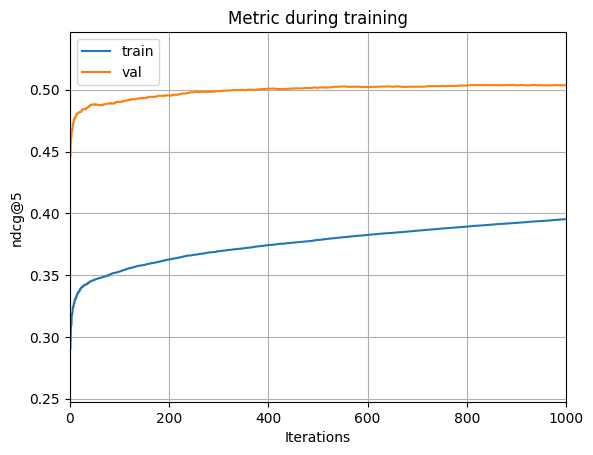

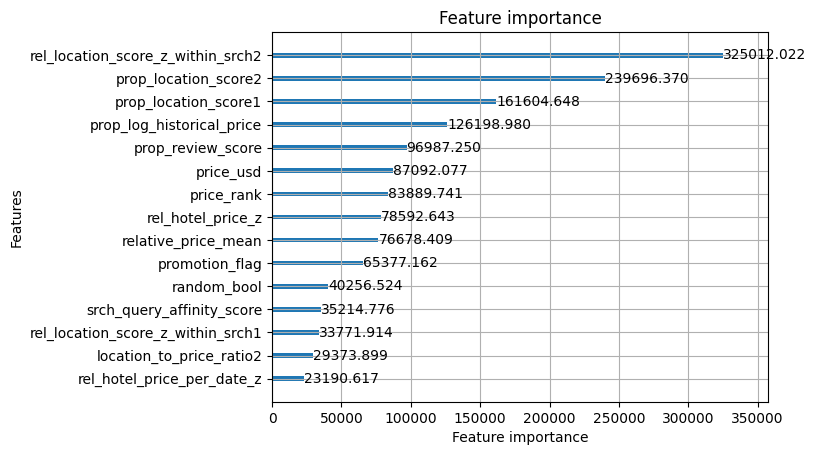

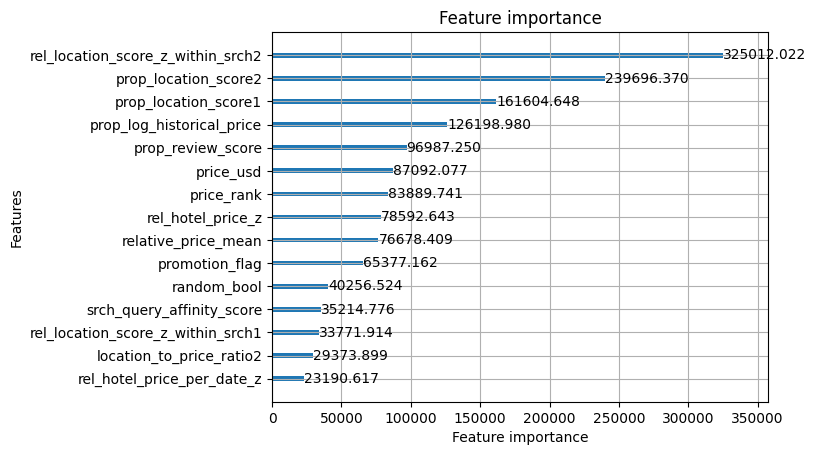

In [175]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def train_model(df_train_preprocessed, df_val_preprocessed, plot: bool = True) -> lgb.LGBMRanker:
    # Prepare target column
    # df_train_preprocessed["target"] = np.where(df_train_preprocessed["click_bool"] == 1, 1, 0)
    # df_train_preprocessed["target"] = np.where(df_train_preprocessed["booking_bool"] == 1, 5, df_train_preprocessed["target"])

    # df_val_preprocessed["target"] = np.where(df_val_preprocessed["click_bool"] == 1, 1, 0)
    # df_val_preprocessed["target"] = np.where(df_val_preprocessed["booking_bool"] == 1, 5, df_val_preprocessed["target"])

    # Using .loc to avoid SettingWithCopyWarning and ensure proper modification
    df_train_preprocessed.loc[:, "target"] = np.where(df_train_preprocessed["click_bool"] == 1, 1, 0)
    df_train_preprocessed.loc[:, "target"] = np.where(df_train_preprocessed["booking_bool"] == 1, 5, df_train_preprocessed["target"])

    df_val_preprocessed.loc[:, "target"] = np.where(df_val_preprocessed["click_bool"] == 1, 1, 0)
    df_val_preprocessed.loc[:, "target"] = np.where(df_val_preprocessed["booking_bool"] == 1, 5, df_val_preprocessed["target"])

    if "prop_id" in df_train_preprocessed.columns:
        df_train_preprocessed.drop(columns=["prop_id"], inplace=True)
        df_val_preprocessed.drop(columns=["prop_id"], inplace=True)


    # Check distribution of target
    target_counts_train = df_train_preprocessed["target"].value_counts()
    print("Distribution of target in train: ")
    print(target_counts_train)

    target_counts_val = df_val_preprocessed["target"].value_counts()
    print("Distribution of target in val: ")
    print(target_counts_val)

    # Assuming the feature columns and the 'srch_id' are already defined in df_train and df_val
    feature_cols = [c for c in df_train_preprocessed.columns if c not in ['srch_id', 'target', 'click_bool', 'booking_bool', 'date_time', 'gross_bookings_usd', 'position', "prop_id_prob_book", "prop_id_prob_click", "prop_id"]]

    X_train = df_train_preprocessed[feature_cols]
    y_train = df_train_preprocessed['target']
    query_size_train = df_train_preprocessed.groupby('srch_id').size().to_list()

    X_val = df_val_preprocessed[feature_cols]
    y_val = df_val_preprocessed['target']
    query_size_val = df_val_preprocessed.groupby('srch_id').size().to_list()

    # LambdaMART model
    model = lgb.LGBMRanker(objective='lambdarank', metric='ndcg', 
                           importance_type='gain',
                           learning_rate=0.05,
                           n_estimators=500,  # Number of boosting rounds (iterations)
                           n_jobs=-1,  # Parallel processing
                           )

    # Train & Validate
    model.fit(
        X=X_train,
        y=y_train,
        group=query_size_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        eval_group=[query_size_train, query_size_val],
        eval_at=[5, 5],
        eval_names=['train', 'val'],
    )

    # Print the best scores after training
    print(model.best_score_)

    # Plotting if requested
    if plot:
        # Loss curves
        lgb.plot_metric(model)
        plt.show()
        plt.close()

        # Feature importance
        # Overall importance
        lgb.plot_importance(model, max_num_features=15)
        plt.show()

        # Importance by gain
        lgb.plot_importance(model, max_num_features=15, importance_type='gain')
        plt.show()

    return model

model = train_model(df_train_preprocessed, df_val_preprocessed, plot=True)


In [ ]:
def get_predictions(model:lgb.LGBMRanker)-> pd.DataFrame:
    # Test output
    # LamdaMART predicts real-valued 'RELEVANCE' independent of grouping
    #   given X_test (without search_id) it predicts relevance for each row
    #   each query can then be sorted by this predicted relevance
    TESTDF = pd.read_csv('data/test_set_VU_DM.csv')
    # add relevant information from date-time 
    preprocessing_test = PreprocessingService(TESTDF, encoder=preprocessing_train.encoder, is_test=True)
    
    TESTDF = preprocessing_test.run(return_numerical=True)
    
    # Produce relevance predictions for each row
    X_test = TESTDF.drop(columns=['srch_id', 'prop_id'])
    predicted_relevance = model.predict(X_test)

    # Add predictions to dataset
    TESTDF['predicted_relevance'] = predicted_relevance

    # Produce ranking predictions for each search ID
    RANKED = TESTDF.sort_values(['srch_id', 'predicted_relevance'], 
                                # from search id 0, ...; within each search id FROM highest relevance)
                                ascending=[True, False]).reset_index(drop=True)

    return RANKED[['srch_id', 'prop_id']] 



TEST_pred = get_predictions(model)
TEST_pred.to_csv('VU-DM-2025-Group-100.csv', index=False)

Running imputations...
Missing values in prop_location_score2: 0
Missing values in the dataset: 113902934
Running feature engineering...
Added time features
Added vacation time features
Added relative price (per query) feature
Added price per person per room feature
Added usually spends vs price feature
Added relative hotel price per date feature (within prop_id)
Added relative hotel price feature (within prop_id)
Added price to location ratio feature
Added domestic trip flag
Added new customer flag
Added price rank feature (within query)
Added relative location scores (1 and 2) feature (within query)
Running encodings...
column site_id has 0 nans
column visitor_location_country_id has 442 nans
column prop_country_id has 0 nans
column prop_id has 19419 nans
column srch_destination_id has 176203 nans
column comp1_rate_percent_diff has 4870189 nans
column comp2_rate_percent_diff has 4405768 nans
column comp3_rate_percent_diff has 4488169 nans


/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/4150781839.py:258: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[f"{col}_prob_click"].fillna(global_mean_click, inplace=True)
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/4150781839.py:263: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

column comp4_rate_percent_diff has 4826237 nans
column comp5_rate_percent_diff has 4119474 nans
column comp6_rate_percent_diff has 4862137 nans
column comp7_rate_percent_diff has 4820172 nans
column comp8_rate_percent_diff has 4348418 nans
Encoded cols using pre-existing encoder and imputed missing values with mean
Binary categorical columns: ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool']
Low cardinality categorical columns: ['prop_starrating', 'comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_inv', 'comp8_rate', 'comp8_inv']
High cardinality categorical columns: ['site_id', 'visitor_location_country_id', 'prop_country_id', 'srch_destination_id', 'comp1_rate_percent_diff', 'comp2_rate_percent_diff', 'comp3_rate_percent_diff', 'comp4_rate_percent_diff', 'comp5_rate_percent_diff', 'comp6_rate_percent_diff', 'comp7_rate_perc

/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/1865265388.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TESTDF['predicted_relevance'] = predicted_relevance


In [123]:
df_test = pd.read_csv('data/test_set_VU_DM.csv')

preprocessing_test = PreprocessingService(df_test, encoder=preprocessing_train.encoder)
df_test_preprocessed = preprocessing_test.run(return_numerical=True)


Running imputations...
Missing values in prop_location_score2: 0
Missing values in the dataset: 113902934
Running feature engineering...
Added time features
Added vacation time features
Added relative price (per query) feature
Added price per person per room feature
Added usually spends vs price feature
Added relative hotel price per date feature (within prop_id)
Added relative hotel price feature (within prop_id)
Added price to location ratio feature
Added domestic trip flag
Added new customer flag
Added price rank feature (within query)
Added relative location scores (1 and 2) feature (within query)
Running encodings...
column site_id has 0 nans
column visitor_location_country_id has 526 nans
column prop_country_id has 97 nans
column prop_id has 19157 nans
column srch_destination_id has 175483 nans
column comp1_rate_percent_diff has 4870214 nans
column comp2_rate_percent_diff has 4405778 nans


/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/2236786899.py:260: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[f"{col}_prob_click"].fillna(global_mean_click, inplace=True)
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_1312/2236786899.py:265: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

column comp3_rate_percent_diff has 4488175 nans
column comp4_rate_percent_diff has 4826239 nans
column comp5_rate_percent_diff has 4119474 nans
column comp6_rate_percent_diff has 4862143 nans
column comp7_rate_percent_diff has 4820183 nans
column comp8_rate_percent_diff has 4348416 nans
Encoded cols using pre-existing encoder and imputed missing values with mean
Binary categorical columns: ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool']
Low cardinality categorical columns: ['prop_starrating', 'comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_inv', 'comp8_rate', 'comp8_inv']
High cardinality categorical columns: ['site_id', 'visitor_location_country_id', 'prop_country_id', 'prop_id', 'srch_destination_id', 'comp1_rate_percent_diff', 'comp2_rate_percent_diff', 'comp3_rate_percent_diff', 'comp4_rate_percent_diff', 'comp5_rate

In [134]:
# check if prop_id in test
print("prop_id in test: ", "prop_id" in df_test_preprocessed.columns)
print("prop_id in train: ", "prop_id" in X_train.columns)
print("prop_id in val: ", "prop_id" in X_val.columns)

prop_id in test:  True
prop_id in train:  False
prop_id in val:  False


In [135]:
print("prop_id in test: ", "prop_id" in df_test.columns)
print("prop_id in train: ", "prop_id" in data.columns)


prop_id in test:  True
prop_id in train:  True
